### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [4]:
import os

# Install Java 17 for PySpark in Colab
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
!update-alternatives --set java /usr/lib/jvm/java-17-openjdk-amd64/bin/java

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [23]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()

**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [6]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [7]:
df.show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [8]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [9]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [10]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [11]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [12]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [13]:
df.createOrReplaceTempView("cars")

In [14]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [15]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [16]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [17]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


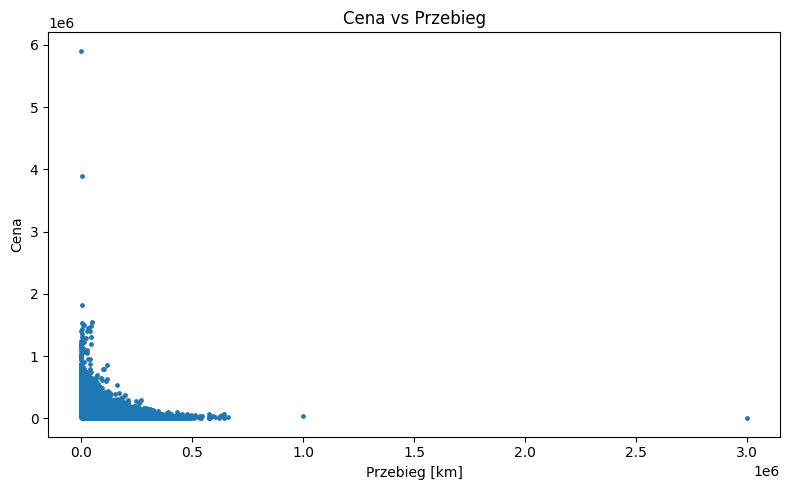

In [18]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [20]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)


spark = SparkSession.builder \
    .appName("Chicago Crimes Analysis") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

In [21]:
#2 Wczytanie danych
df_crimes = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/content/chicago_crimes_sample.csv")

df_crimes.show(5)
df_crimes.printSchema()

+-------------+--------------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|           id|   case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|
+-------------+--------------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|     14193193|      JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...|0820|       THEFT|      $500 AND UNDER|              STREET| false|   false| 811|       8|  13|

In [25]:
from pyspark.sql.types import IntegerType, BooleanType
from pyspark.sql.functions import to_timestamp, col, hour

#3 Czyszczenie danych

# usuwanie duplikatow
df_clean = df_crimes.dropDuplicates()

# Konwersja daty
df_clean = df_clean.withColumn(
    "Date_parsed",
    to_timestamp(col("date"))
)

# usuwanie brakow
key_columns = ["id", "date", "primary_type", "location_description", "arrest", "year"]

df_clean = df_clean.dropna(subset=key_columns)

# usuwanie blednych dat
df_clean = df_clean.filter(col("Date_parsed").isNotNull())

#poprawa typow
df_clean = df_clean.withColumn("year", col("year").cast(IntegerType())) \
                   .withColumn("Hour", hour(col("Date_parsed"))) \
                   .withColumn("arrest", col("arrest").cast(BooleanType()))

#
df_clean = df_clean.filter((col("year") >= 2001) & (col("year") <= 2030))

df_clean.show(5)

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+-------------------+----+
|      id|case_number|               date|               block|iucr|        primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|        Date_parsed|Hour|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+-------------------+----+
|14189355|   JK244986|2026-05-06 23:15:00| 047XX S DREXEL BLVD|2860|PUBLIC PEACE VIOL...| F

In [28]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def klasyfikuj_pore_dnia(h):
    if h is None:
        return "brak"
    if h < 6:
        return "noc"
    elif h < 12:
        return "rano"
    elif h < 18:
        return "dzien"
    else:
        return "wieczor"

pora_dnia_udf = udf(klasyfikuj_pore_dnia, StringType())

df_clean = df_clean.withColumn("pora_dnia", pora_dnia_udf(col("Hour")))

df_clean.select("date", "Hour", "pora_dnia").show(10)

+-------------------+----+---------+
|               date|Hour|pora_dnia|
+-------------------+----+---------+
|2026-05-06 23:15:00|  23|  wieczor|
|2026-05-06 23:10:00|  23|  wieczor|
|2026-05-06 23:07:00|  23|  wieczor|
|2026-05-06 23:00:00|  23|  wieczor|
|2026-05-06 22:36:00|  22|  wieczor|
|2026-05-06 22:31:00|  22|  wieczor|
|2026-05-06 22:20:00|  22|  wieczor|
|2026-05-06 21:37:00|  21|  wieczor|
|2026-05-06 21:35:00|  21|  wieczor|
|2026-05-06 21:30:00|  21|  wieczor|
+-------------------+----+---------+
only showing top 10 rows


In [29]:
df_clean.cache()
df_clean.count()

49803

In [30]:
# Najpopularniejsze typy przestępstw
df_clean.groupBy("primary_type") \
    .count() \
    .orderBy(col("count").desc()) \
    .show(20, False)

+--------------------------------+-----+
|primary_type                    |count|
+--------------------------------+-----+
|THEFT                           |10920|
|BATTERY                         |9253 |
|CRIMINAL DAMAGE                 |5497 |
|ASSAULT                         |4564 |
|MOTOR VEHICLE THEFT             |3886 |
|OTHER OFFENSE                   |3459 |
|BURGLARY                        |3163 |
|DECEPTIVE PRACTICE              |2486 |
|NARCOTICS                       |1455 |
|CRIMINAL TRESPASS               |1193 |
|WEAPONS VIOLATION               |1022 |
|ROBBERY                         |916  |
|OFFENSE INVOLVING CHILDREN      |368  |
|CRIMINAL SEXUAL ASSAULT         |331  |
|SEX OFFENSE                     |306  |
|PUBLIC PEACE VIOLATION          |256  |
|INTERFERENCE WITH PUBLIC OFFICER|205  |
|STALKING                        |132  |
|HOMICIDE                        |94   |
|ARSON                           |91   |
+--------------------------------+-----+
only showing top

In [31]:
# Typ przestępstwa według lokalizacji
df_clean.groupBy("location_description", "primary_type") \
    .count() \
    .orderBy(col("count").desc()) \
    .show(30, False)

+--------------------------------------+-------------------+-----+
|location_description                  |primary_type       |count|
+--------------------------------------+-------------------+-----+
|APARTMENT                             |BATTERY            |3019 |
|STREET                                |MOTOR VEHICLE THEFT|2957 |
|STREET                                |THEFT              |2288 |
|STREET                                |CRIMINAL DAMAGE    |2104 |
|STREET                                |BURGLARY           |1540 |
|APARTMENT                             |THEFT              |1438 |
|STREET                                |BATTERY            |1385 |
|RESIDENCE                             |BATTERY            |1347 |
|SMALL RETAIL STORE                    |THEFT              |1208 |
|APARTMENT                             |OTHER OFFENSE      |1194 |
|APARTMENT                             |ASSAULT            |1167 |
|APARTMENT                             |CRIMINAL DAMAGE    |10

In [32]:
# Typ przestępstwa według pory dnia
df_clean.groupBy("pora_dnia", "primary_type") \
    .count() \
    .orderBy(col("count").desc()) \
    .show(30, False)

+---------+-------------------+-----+
|pora_dnia|primary_type       |count|
+---------+-------------------+-----+
|dzien    |THEFT              |4307 |
|dzien    |BATTERY            |2824 |
|wieczor  |BATTERY            |2814 |
|wieczor  |THEFT              |2637 |
|rano     |THEFT              |2563 |
|noc      |BATTERY            |1866 |
|rano     |BATTERY            |1749 |
|dzien    |ASSAULT            |1646 |
|wieczor  |CRIMINAL DAMAGE    |1627 |
|noc      |CRIMINAL DAMAGE    |1465 |
|wieczor  |MOTOR VEHICLE THEFT|1440 |
|noc      |THEFT              |1413 |
|dzien    |CRIMINAL DAMAGE    |1305 |
|wieczor  |ASSAULT            |1210 |
|dzien    |OTHER OFFENSE      |1154 |
|rano     |ASSAULT            |1128 |
|rano     |CRIMINAL DAMAGE    |1100 |
|dzien    |DECEPTIVE PRACTICE |1070 |
|wieczor  |OTHER OFFENSE      |928  |
|rano     |OTHER OFFENSE      |921  |
|wieczor  |BURGLARY           |915  |
|noc      |BURGLARY           |909  |
|dzien    |MOTOR VEHICLE THEFT|881  |
|noc      |M

In [33]:
# Najpopularniejsze lokalizacje
df_clean.groupBy("location_description") \
    .count() \
    .orderBy(col("count").desc()) \
    .show(20, False)

+--------------------------------------+-----+
|location_description                  |count|
+--------------------------------------+-----+
|STREET                                |13979|
|APARTMENT                             |9802 |
|RESIDENCE                             |5692 |
|SIDEWALK                              |2308 |
|PARKING LOT / GARAGE (NON RESIDENTIAL)|1842 |
|SMALL RETAIL STORE                    |1708 |
|DEPARTMENT STORE                      |1147 |
|RESTAURANT                            |1107 |
|ALLEY                                 |991  |
|VEHICLE NON-COMMERCIAL                |923  |
|OTHER (SPECIFY)                       |878  |
|COMMERCIAL / BUSINESS OFFICE          |747  |
|RESIDENCE - PORCH / HALLWAY           |625  |
|GROCERY FOOD STORE                    |570  |
|GAS STATION                           |550  |
|RESIDENCE - YARD (FRONT / BACK)       |453  |
|BAR OR TAVERN                         |390  |
|CONVENIENCE STORE                     |371  |
|SCHOOL - PUB

In [35]:
# Statystyka aresztowan
from pyspark.sql.functions import avg, sum, round, count

df_clean.groupBy("primary_type") \
    .agg(
        count("*").alias("liczba_zdarzen"),
        sum(col("arrest").cast("int")).alias("liczba_aresztowan"),
        round(avg(col("arrest").cast("int")) * 100, 2).alias("procent_aresztowan")
    ) \
    .orderBy(col("liczba_zdarzen").desc()) \
    .show(20, False)

+--------------------------------+--------------+-----------------+------------------+
|primary_type                    |liczba_zdarzen|liczba_aresztowan|procent_aresztowan|
+--------------------------------+--------------+-----------------+------------------+
|THEFT                           |10920         |993              |9.09              |
|BATTERY                         |9253          |1668             |18.03             |
|CRIMINAL DAMAGE                 |5497          |253              |4.6               |
|ASSAULT                         |4564          |586              |12.84             |
|MOTOR VEHICLE THEFT             |3886          |150              |3.86              |
|OTHER OFFENSE                   |3459          |529              |15.29             |
|BURGLARY                        |3163          |85               |2.69              |
|DECEPTIVE PRACTICE              |2486          |60               |2.41              |
|NARCOTICS                       |1455     

In [36]:
heavy = df_clean.groupBy(
    "year",
    "location_description",
    "primary_type",
    "pora_dnia"
).agg(
    count("*").alias("liczba_zdarzen"),
    sum(col("arrest").cast("int")).alias("liczba_aresztowan")
).orderBy(col("liczba_zdarzen").desc())

heavy.show(20, False)

heavy.explain(True)

+----+--------------------+-------------------+---------+--------------+-----------------+
|year|location_description|primary_type       |pora_dnia|liczba_zdarzen|liczba_aresztowan|
+----+--------------------+-------------------+---------+--------------+-----------------+
|2026|STREET              |MOTOR VEHICLE THEFT|wieczor  |1151          |29               |
|2026|APARTMENT           |BATTERY            |wieczor  |943           |185              |
|2026|APARTMENT           |BATTERY            |dzien    |744           |138              |
|2026|APARTMENT           |BATTERY            |noc      |712           |178              |
|2026|STREET              |THEFT              |wieczor  |698           |11               |
|2026|STREET              |MOTOR VEHICLE THEFT|noc      |688           |24               |
|2026|STREET              |CRIMINAL DAMAGE    |wieczor  |666           |36               |
|2026|STREET              |MOTOR VEHICLE THEFT|dzien    |627           |34               |

In [37]:
df_clean.write \
    .mode("overwrite") \
    .partitionBy("year") \
    .parquet("/content/chicago_crimes_parquet")